# Check Tracking and Trajectory Processing

In [1]:
import os
if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")

from src_final.tracking.tracker import MediapipeHandTracker
from src_final.tracking.preprocessing import TrajectoryProcessor, LandmarksProcessor
from src_final.tracking.visualization import draw_hands, draw_hand_trajectories, draw_raw_vs_processed_trajectories
from tqdm import tqdm
import pandas as pd

In [2]:
import mediapipe as mp
print(mp.__version__)

0.10.21


In [3]:
FPS = 30

if FPS == 30:
    max_jump_px = 100
    max_gap_sec = 0.1
else:
    max_jump_px = 100
    max_gap_sec = 0.2

tracker = MediapipeHandTracker(target_fps=FPS)
processor = LandmarksProcessor(fps=FPS, max_jump_px=max_jump_px, max_gap_sec=max_gap_sec)

In [115]:
video_path = "data/videos/Study1_Videos/2024-01-24_15-52-33.mp4"
#video_path = "data/videos/Study1_Videos/test_clip.mp4"
df = tracker.track_video(video_path, overwrite=False)
df_processed = processor.process(df)

⏭️ Skipping 2024-01-24_15-52-33 (already processed)


In [6]:
df_processed.head()


,frame,hand_label,hand_score,palm_center,frame_diff,segment_id,lm_0_x_smooth,lm_0_y_smooth,lm_5_x_smooth,lm_5_y_smooth,lm_17_x_smooth,lm_17_y_smooth,cx_smooth,cy_smooth
0,89,Left,0.783614,"(431.18417739868164, 628.6777675151825)",NaN,0,474.837121,607.476485,420.308091,657.754242,402.245212,605.210909,429.708128,627.892451
1,90,Left,0.806477,"(430.0643539428711, 634.6967732906342)",1.0,0,474.716364,608.833121,420.316106,658.413561,403.651636,606.647727,429.896782,629.190590
2,91,Left,0.540491,"(424.8857355117798, 629.4616377353668)",1.0,0,474.695108,609.911338,420.264403,659.073669,404.768558,607.522359,430.053533,630.246917
3,92,Left,0.819768,"(429.54073429107666, 628.068037033081)",1.0,0,474.773355,610.711134,420.152981,659.734567,405.595978,607.834805,430.178380,631.061432
4,93,Left,0.538915,"(429.7629976272583, 630.7606852054596)",1.0,0,474.951104,611.232511,419.981840,660.396255,406.133896,607.585065,430.271324,631.634135


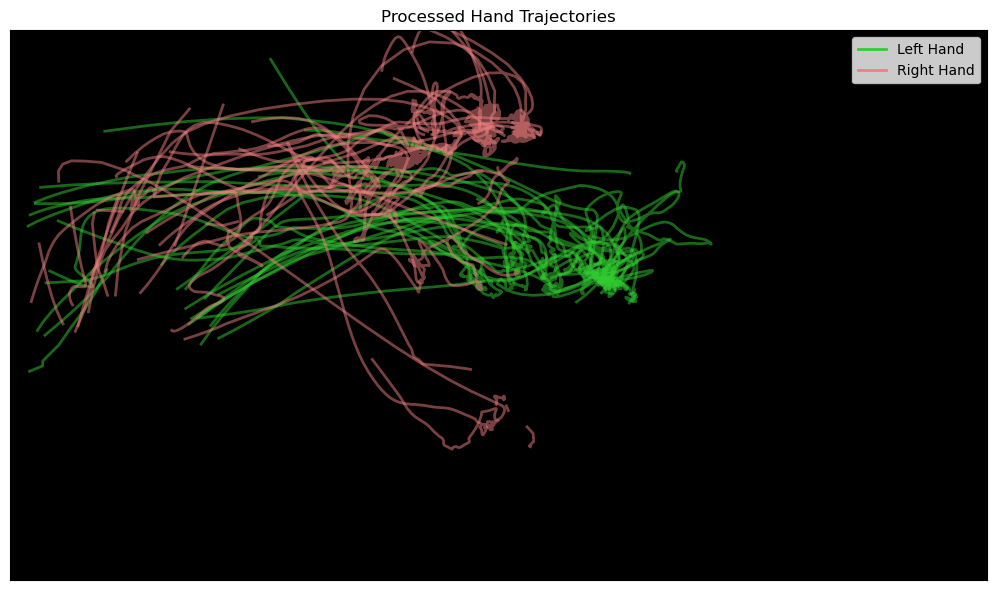

In [116]:
df_hand_left = df_processed[df_processed['hand_label'] == 'Left']
df_hand_right = df_processed[df_processed['hand_label'] == 'Right']
draw_hands(df_hand_left, df_hand_right, title="Processed Hand Trajectories")

#df_hand_left_old = df_processed_old[df_processed_old['hand_label'] == 'Left']
#df_hand_right_old = df_processed_old[df_processed_old['hand_label'] == 'Right']
#draw_hands(df_hand_left_old, df_hand_right_old, title="Old Processed Hand Trajectories")

In [ ]:
draw_raw_vs_processed_trajectories(
    video_path=video_path,
    raw_df=df_raw,
    processed_df=df_processed,
    output_path="data/experiments/short_raw_vs_processed.mp4",
    tail_length=30,
    show_landmarks=("palm_center", "0", "5", "17"),
    show_raw=True,
    show_processed=True,
)

Drawing trajectories for: 2024-01-15_16-17-19


100%|██████████| 9535/9535 [04:13<00:00, 37.65frames/s]

✅ Video saved to: data/experiments/2024-01-15_16-17-19_trajectories_30fps.mp4


'data/experiments/2024-01-15_16-17-19_trajectories_30fps.mp4'

## Process all dataframes

In [4]:
FPS = 30
if FPS == 30:
    max_jump_px = 100
    max_gap_sec = 0.2
else:
    max_jump_px = 100
    max_gap_sec = 0.2

# Just remeber that in final git repo, the videos won't be so I need to add add this list manually somewhere
video_dir = "data/Videos/Study1_videos"
study_videos = [v for v in os.listdir(video_dir) if v.startswith('2024')]

processed_dir = "data/processed/landmark_dataframes2/"
processed_dataframes = [f for f in os.listdir(processed_dir) if f.endswith(f'_{FPS}fps_processed.pkl')]

tracker = MediapipeHandTracker(target_fps=FPS)
processor = LandmarksProcessor(fps=FPS, max_jump_px=max_jump_px, max_gap_sec=max_gap_sec)

for video in tqdm(study_videos, desc="Processing videos"):
    # skip if already processed
    processed_filename = video.replace(f'.mp4', f'_{FPS}fps_processed.pkl')
    #if processed_filename in processed_dataframes:
    #    print(f"Skipping {video} as it is already processed.")
    #    continue

    df_tracked = tracker.track_video(os.path.join(video_dir, video), overwrite=False)
    processed_df = processor.process(df_tracked)
    processed_df.to_pickle(os.path.join(processed_dir, video.replace(f'.mp4', f'_{FPS}fps_processed.pkl')))

Processing videos:   0%|          | 0/86 [00:00<?, ?it/s]

⏭️ Skipping 2024-01-22_11-22-50 (already processed)


Processing videos:   1%|          | 1/86 [00:17<25:23, 17.93s/it]

⏭️ Skipping 2024-01-24_09-56-13 (already processed)


Processing videos:   2%|▏         | 2/86 [00:32<22:35, 16.14s/it]

...

Processing videos:  98%|█████████▊| 84/86 [19:23<00:24, 12.28s/it]

⏭️ Skipping 2024-01-16_16-03-11 (already processed)


Processing videos:  99%|█████████▉| 85/86 [19:54<00:17, 17.82s/it]

⏭️ Skipping 2024-01-22_11-03-50 (already processed)


Processing videos: 100%|██████████| 86/86 [20:11<00:00, 14.09s/it]


## Generate Figure (X)

In [ ]:
FPS = 30
max_jump_px = 100
max_gap_sec = 0.1

video_path = "data/videos/Study1_Videos/short_final_img.mp4"
out_path = "data/experiments/short_final_img_tracking_overlay.mp4"

tracker = MediapipeHandTracker(target_fps=30)

tracker = MediapipeHandTracker(target_fps=FPS)
processor = LandmarksProcessor(fps=FPS, max_jump_px=max_jump_px, max_gap_sec=max_gap_sec)

df_raw = tracker.track_video(video_path, overwrite=False)
#df_processed = processor.process(df_raw)

I0000 00:00:1773159990.526817 10050895 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-23.0.22), renderer: Intel(R) Iris(TM) Plus Graphics OpenGL Engine


▶️ Tracking hands in short_final_img ...


Processing frames:   0%|                                                   | 0/5462 [00:00<?, ?it/s]W0000 00:00:1773159990.597339 10284061 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773159990.630602 10284068 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Processing frames: 100%|████████████████████████████▉| 5457/5462 [03:04<00:00, 29.53it/s, FPS=33.94]


✅ Saved DataFrame: data/raw/output_dataframes/hand_tracking_short_final_img_30fps.pkl (9812 rows)


In [137]:
import os
import cv2
import mediapipe as mp
import pandas as pd
from google.protobuf.json_format import ParseDict
from mediapipe.framework.formats import landmark_pb2
import time


class MediapipeHandTracker:
    """
    Wrapper for Mediapipe hand tracking:
    - tracks left + right hand
    - extracts bbox centers, palm centers, all landmarks
    - supports FPS downsampling
    - saves results as .pkl DataFrames
    """

    def __init__(
        self,
        target_fps=30,
        min_detection_conf=0.5,
        min_tracking_conf=0.5,
        max_num_hands=2
    ):
        self.target_fps = target_fps
        self.min_detection_conf = min_detection_conf
        self.min_tracking_conf = min_tracking_conf
        self.max_num_hands = max_num_hands

        self.mp_hands = mp.solutions.hands
        self.mp_drawing = mp.solutions.drawing_utils
        self.mp_drawing_styles = mp.solutions.drawing_styles

    # ---------------------------------------------------------
    # Core API call
    # ---------------------------------------------------------
    def track_video(self, video_path, output_dir="data/raw/output_dataframes", overwrite=False):
        """
        Tracks hands in a single video and returns dataframe.
        """

        os.makedirs(output_dir, exist_ok=True)
        vid_name = os.path.splitext(os.path.basename(video_path))[0]
        output_path = os.path.join(
            output_dir,
            f"hand_tracking_{vid_name}_{self.target_fps}fps.pkl"
        )

        if os.path.exists(output_path) and not overwrite:
            print(f"⏭️ Skipping {vid_name} (already processed)")
            return pd.read_pickle(output_path)

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"❌ Cannot open {video_path}")
            return None

        fps_video = cap.get(cv2.CAP_PROP_FPS)
        num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_step = int(round(fps_video / self.target_fps)) if fps_video > self.target_fps else 1

        hands = self.mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=self.max_num_hands,
            min_detection_confidence=self.min_detection_conf,
            min_tracking_confidence=self.min_tracking_conf
        )

        all_data = []
        frame_idx = 0
        prev_time = time.time()

        print(f"▶️ Tracking hands in {vid_name} ...")
        with tqdm(total=num_frames // frame_step, desc="Processing frames", ncols=100) as pbar:
            while cap.isOpened():
                success, frame = cap.read()
                if not success:
                    break

                if frame_idx % frame_step != 0:
                    frame_idx += 1
                    continue

                frame_data = self._process_frame(frame, frame_idx, hands)
                all_data.extend(frame_data)

                curr_time = time.time()
                fps_display = 1 / (curr_time - prev_time) if prev_time else 0
                prev_time = curr_time
                pbar.set_postfix({"FPS": f"{fps_display:.2f}"})
                pbar.update(1)

                frame_idx += 1

        cap.release()
        hands.close()

        df = pd.DataFrame(all_data)
        df.to_pickle(output_path)
        print(f"✅ Saved DataFrame: {output_path} ({df.shape[0]} rows)")

        return df

    # ---------------------------------------------------------
    # Helper: process a single frame
    # ---------------------------------------------------------
    def _process_frame(self, frame, frame_idx, hands_model):
        """
        Run Mediapipe on one frame and extract data for both hands.
        Returns a list of dicts (one per detected hand or one empty row).
        """

        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands_model.process(image_rgb)
        h, w, _ = frame.shape

        frame_output = []

        if results.multi_hand_landmarks and results.multi_handedness:
            for hand_lm, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
                label = handedness.classification[0].label
                score = handedness.classification[0].score

                xs = [lm.x for lm in hand_lm.landmark]
                ys = [lm.y for lm in hand_lm.landmark]

                x_min, x_max = int(min(xs) * w), int(max(xs) * w)
                y_min, y_max = int(min(ys) * h), int(max(ys) * h)

                bbox_center = (round((x_min + x_max) / 2), round((y_min + y_max) / 2))

                palm_indices = [0, 1, 5, 9, 13, 17]
                palm_cx = np.mean([xs[i] for i in palm_indices]) * w
                palm_cy = np.mean([ys[i] for i in palm_indices]) * h
                palm_center = (round(palm_cx), round(palm_cy))

                landmarks_array = [
                    {"id": i, "coord": (lm.x, lm.y, lm.z)}
                    for i, lm in enumerate(hand_lm.landmark)
                ]

                frame_output.append({
                    "frame": frame_idx,
                    "hand_label": label,
                    "hand_score": score,
                    "bbox_center": bbox_center,
                    "palm_center": palm_center,
                    "landmarks": landmarks_array
                })
        else:
            frame_output.append({
                "frame": frame_idx,
                "hand_label": None,
                "hand_score": None,
                "bbox_center": (None, None),
                "palm_center": (None, None),
                "landmarks": None
            })

        return frame_output

    # ---------------------------------------------------------
    # Helper: rebuild MediaPipe landmark object from dataframe row
    # ---------------------------------------------------------
    def _landmarks_from_row(self, landmarks_list):
        """
        Convert stored landmark list
        [{'id': i, 'coord': (x, y, z)}, ...]
        back into a MediaPipe NormalizedLandmarkList.
        """
        if not isinstance(landmarks_list, list):
            return None

        lm_dict = {}
        for item in landmarks_list:
            if not isinstance(item, dict):
                continue
            lm_id = item.get("id")
            coord = item.get("coord")
            if lm_id is None or coord is None or len(coord) < 3:
                continue
            lm_dict[int(lm_id)] = coord

        if len(lm_dict) == 0:
            return None

        landmark_list = landmark_pb2.NormalizedLandmarkList()
        for i in range(21):
            if i in lm_dict:
                x, y, z = lm_dict[i]
            else:
                x, y, z = 0.0, 0.0, 0.0

            landmark = landmark_list.landmark.add()
            landmark.x = float(x)
            landmark.y = float(y)
            landmark.z = float(z)

        return landmark_list

    # ---------------------------------------------------------
    # Overlay tracked landmarks from dataframe onto video
    # ---------------------------------------------------------
    def render_tracking_overlay_video(
        self,
        video_path,
        tracking_df,
        output_path=None,
        show_label=True,
        show_score=True,
        show_frame_idx=False,
        overwrite=False
    ):
        """
        Render a video with MediaPipe-style hand overlay using an existing tracking dataframe.

        Parameters
        ----------
        video_path : str
            Path to original input video.
        tracking_df : pd.DataFrame
            DataFrame produced by track_video().
        output_path : str or None
            Path to save rendered video. If None, saves next to input video.
        show_label : bool
            Whether to draw Left/Right label.
        show_score : bool
            Whether to draw hand confidence score.
        show_frame_idx : bool
            Whether to draw frame index.
        overwrite : bool
            Whether to overwrite existing file.

        Returns
        -------
        str
            Path to saved overlay video.
        """
        if output_path is None:
            base = os.path.splitext(os.path.basename(video_path))[0]
            output_dir = os.path.join(os.path.dirname(video_path), "output_videos")
            os.makedirs(output_dir, exist_ok=True)
            output_path = os.path.join(output_dir, f"tracked_{base}.mp4")

        if os.path.exists(output_path) and not overwrite:
            print(f"⏭️ Output already exists: {output_path}")
            return output_path

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise IOError(f"Cannot open video file: {video_path}")

        fps_video = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out = cv2.VideoWriter(output_path, fourcc, fps_video, (width, height))

        # keep only valid rows with a detected hand
        df = tracking_df.copy()
        df = df[df["hand_label"].notna()].copy()

        # group rows by frame for fast lookup
        rows_by_frame = {frame: grp for frame, grp in df.groupby("frame")}

        frame_idx = 0
        print("▶️ Rendering tracking overlay video...")

        while True:
            success, frame = cap.read()
            if not success:
                break

            if frame_idx in rows_by_frame:
                frame_rows = rows_by_frame[frame_idx]

                for _, row in frame_rows.iterrows():
                    hand_landmarks = self._landmarks_from_row(row["landmarks"])
                    if hand_landmarks is None:
                        continue
                    
                    # --- Draw normal skeleton (neutral color) ---
                    landmark_style = self.mp_drawing.DrawingSpec(
                        color=(200, 200, 200),  # light gray
                        thickness=2,
                        circle_radius=2
                    )

                    connection_style = self.mp_drawing.DrawingSpec(
                        color=(200, 200, 200),
                        thickness=2
                    )

                    self.mp_drawing.draw_landmarks(
                        frame,
                        hand_landmarks,
                        self.mp_hands.HAND_CONNECTIONS,
                        landmark_style,
                        connection_style,
                    )

                    # --- Highlight palm landmarks ---
                    palm_indices = [0, 1, 5, 9, 13, 17]

                    h, w, _ = frame.shape

                    for idx in palm_indices:
                        lm = hand_landmarks.landmark[idx]

                        x = int(lm.x * w)
                        y = int(lm.y * h)

                        cv2.circle(
                            frame,
                            (x, y),
                            6,                # larger radius
                            (0, 0, 255),      # red highlight
                            -1
                        )
                    
                    # --- Draw the palm center ---
                    palm_center = row["palm_center"]
                    if (
                        isinstance(palm_center, (tuple, list)) and
                        len(palm_center) == 2 and
                        pd.notna(palm_center[0]) and
                        pd.notna(palm_center[1])
                    ):
                        cx = int(round(float(palm_center[0])))
                        cy = int(round(float(palm_center[1])))
                        cv2.circle(frame, (cx, cy), 8, (255, 0, 0), -1)

                    # label position: use top-left landmark extent
                    xs = [lm.x for lm in hand_landmarks.landmark]
                    ys = [lm.y for lm in hand_landmarks.landmark]
                    x_min = int(min(xs) * width)
                    y_min = int(min(ys) * height)

                    text_parts = []
                    if show_label:
                        text_parts.append(str(row["hand_label"]))
                    if show_score and pd.notna(row.get("hand_score", None)):
                        text_parts.append(f"{float(row['hand_score']):.2f}")

                    if text_parts:
                        label_text = " | ".join(text_parts)
                        cv2.putText(
                            frame,
                            label_text,
                            (x_min, max(25, y_min - 10)),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.7,
                            (0, 255, 0),
                            2,
                            cv2.LINE_AA,
                        )

            if show_frame_idx:
                cv2.putText(
                    frame,
                    f"Frame: {frame_idx}",
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (0, 255, 0),
                    2,
                    cv2.LINE_AA,
                )

            out.write(frame)
            frame_idx += 1

        cap.release()
        out.release()
        cv2.destroyAllWindows()
        print(f"✅ Video saved successfully: {output_path}")

        return output_path

    # ---------------------------------------------------------
    # Batch processing wrapper
    # ---------------------------------------------------------
    def process_directory(
        self,
        input_dir,
        output_dir="output_dataframes",
        batch_size=5,
        overwrite=False
    ):
        """
        Process up to batch_size unprocessed videos in a directory.
        """

        os.makedirs(output_dir, exist_ok=True)

        videos = [
            os.path.join(input_dir, f)
            for f in os.listdir(input_dir)
            if f.lower().endswith(".mp4")
        ]

        processed_files = {
            f.split("_", 2)[1]: f
            for f in os.listdir(output_dir)
            if f.endswith(f"{self.target_fps}fps.pkl")
        }

        unprocessed = [
            v for v in videos
            if os.path.splitext(os.path.basename(v))[0] not in processed_files
        ]

        if not unprocessed:
            print("✅ All videos already processed.")
            return []

        print(f"🔹 Found {len(unprocessed)} unprocessed videos, processing up to {batch_size}...")

        results = []
        for v in unprocessed[:batch_size]:
            out_path = self.track_video(v, output_dir=output_dir, overwrite=overwrite)
            if out_path is not None:
                results.append(out_path)

        return results

In [138]:
overlay_path = tracker.render_tracking_overlay_video(
    video_path=video_path,
    tracking_df=df_raw,
    output_path=out_path,
    show_label=True,
    show_score=True,
    show_frame_idx=False,
    overwrite=True
)

print(overlay_path)

▶️ Rendering tracking overlay video...
✅ Video saved successfully: data/experiments/short_final_img_tracking_overlay.mp4
data/experiments/short_final_img_tracking_overlay.mp4


In [111]:
video_path = "data/videos/Study1_Videos/2024-01-24_15-52-33.mp4"

tracker = MediapipeHandTracker(target_fps=FPS)
processor = LandmarksProcessor(fps=FPS, max_jump_px=max_jump_px, max_gap_sec=max_gap_sec)

raw_df = tracker.track_video(video_path, overwrite=False)
df_processed = processor.process(raw_df)

⏭️ Skipping 2024-01-24_15-52-33 (already processed)


Image dimensions: width=1920, height=1077


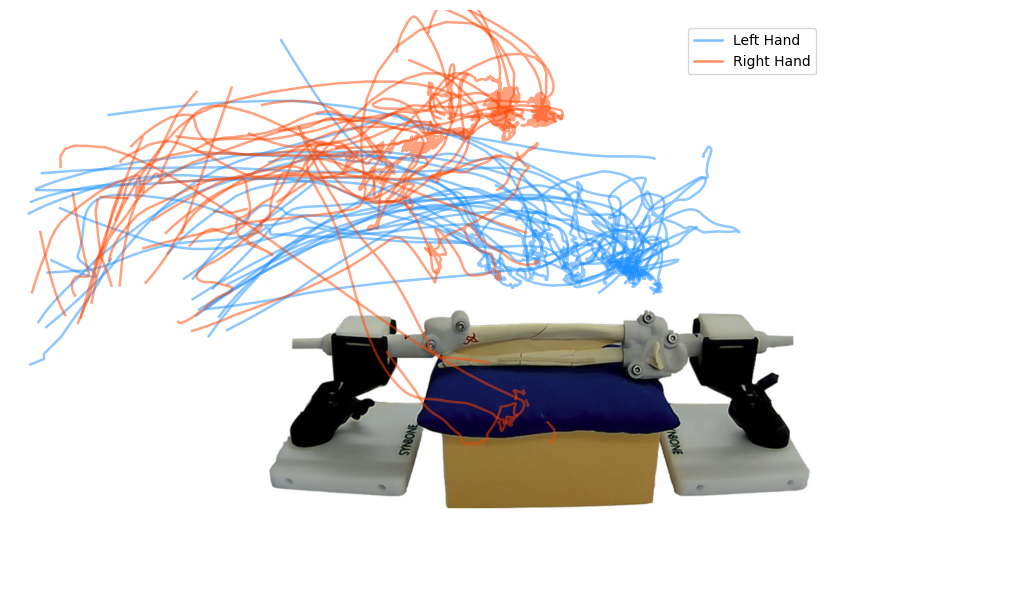

In [165]:

df_hand_left = df_processed[df_processed['hand_label'] == 'Left']
df_hand_right = df_processed[df_processed['hand_label'] == 'Right']
draw_hands(df_hand_left, df_hand_right, title="Processed Hand Trajectories", background="data/experiments/background2.png")